## **Scientific Computing: Coffee Production Analysis**

### **0. SETUP**

0.1 Import Libraries

In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import trapezoid

0.2 Load Dataset

In [ ]:
#Load Dataset
df = pd.read_excel("coffee_production_monthly.xlsx", engine = "openpyxl")

0.3 Data Overview

In [3]:
#Extract M1-M144 columns
month_cols = sorted(
    [c for c in df.columns if c.startswith('M')],
    key= lambda x: int(x[1:])
)

y = df.loc[0, month_cols].astype(float).values
x = np.arange(1, len(y) + 1)

#Put into DataFrame
data = pd.DataFrame({"Month": x, "Production": y})

print("Total Data :", len(x))
print("Top 5 Production:")
data.head()

Total Data : 144
Top 5 Production:


,Month,Production
0,1,1863.0
1,2,1614.0
2,3,2570.0
3,4,1685.0
4,5,2101.0


### **A. Regression Exponential vs 3rd Order Polynomial**

Regression Exponential: a.e^(bx)

In [4]:
#Define exponential function
def exp_func(x, a, b):
    return a*np.exp(b*x)

#Fit exponential model using curve_fit for better accuracy
popt_exp, _ = curve_fit(exp_func, x, y, p0=[2000, 0.015])
y_pred_exp = exp_func(x, *popt_exp)

3rd Order Polynomial

In [5]:
#Fit polynomial order 3
poly_coeffs = np.polyfit(x, y, 3)
y_pred_poly = np.polyval(poly_coeffs, x)

In [6]:
#Function to calculate R2
def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot

#Calculate R2 for both models
r2_exp = calculate_r2(y, y_pred_exp)
r2_poly = calculate_r2(y, y_pred_poly)

# Print parameters and R2
print("Exponential Model Parameters: a = {:.3f}, b = {:.3f}".format(*popt_exp))
print("Exponential R2: {:.6f}".format(r2_exp))
print("3rd Order Polynomial Coefficients:", poly_coeffs)
print("Polynomial R2: {:.6f}".format(r2_poly))

# Determine optimal model
if r2_exp > r2_poly:
    print("Exponential model is more optimal based on higher R2.")
    optimal_model = 'exp'
    optimal_params = popt_exp
    def optimal_func(x_val):
        return exp_func(x_val, *optimal_params)
else:
    print("Polynomial model is more optimal based on higher R².")
    optimal_model = 'poly'
    optimal_params = poly_coeffs
    def optimal_func(x_val):
        return np.polyval(optimal_params, x_val)

Exponential Model Parameters: a = 1991.285, b = 0.015
Exponential R2: 0.995612
3rd Order Polynomial Coefficients: [ 3.86326992e-03 -1.34357030e-01  4.72235525e+01  1.74850672e+03]
Polynomial R2: 0.995583
Exponential model is more optimal based on higher R2.


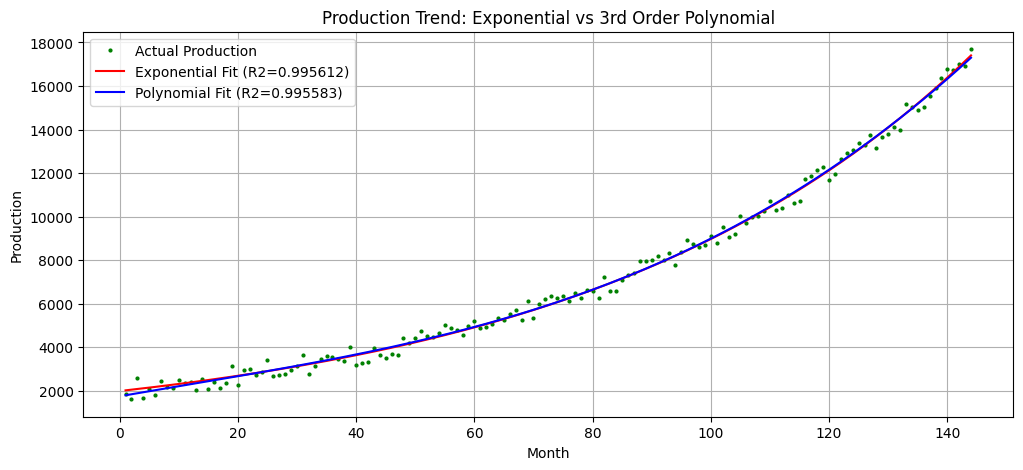

In [7]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(x, y, 'g.', label= "Actual Production", markersize=4)
plt.plot(x, y_pred_exp, 'r-', label= "Exponential Fit (R2={:.6f})".format(r2_exp))
plt.plot(x, y_pred_poly, 'b-', label= "Polynomial Fit (R2={:.6f})".format(r2_poly))
plt.title("Production Trend: Exponential vs 3rd Order Polynomial")
plt.xlabel("Month")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

The production data exhibits an accelerating non-linear growth pattern. The exponential regression closely follows the observed production trend and achieves an R2 of 0.995612, indicating that it provides a strong representation of the historical production pattern and is more suitable for extrapolating future production growth.

### **B. Taylor Series Approximation**

In [8]:
#Define Taylor Function
def taylor_approx(x, a, b, n_terms= 20):
    bx = b*x
    approx = 0.0
    term = 1.0
    for k in range(n_terms):
        approx += term
        term *= bx / (k+1)
    return a*approx

In [9]:
print("Taylor Series Approximation for Exponential Model (20 terms for high accuracy)")
print("=" * 78)

#Accuracy check
for test_x in [1, 72, 144]:
    exact = optimal_func(test_x)
    approx = taylor_approx(test_x, *optimal_params)
    error = abs(exact - approx)
    print(f"At x = {test_x:3d} | exact = {exact:10.4f} | approx = {approx:10.4f} | error = {error:.4e}")

print("\nExplanation: Taylor series provides a polynomial approximation of the exponential function, ensuring high accuracy with sufficient terms (error < 1e-7 for x up to 170).")

Taylor Series Approximation for Exponential Model (20 terms for high accuracy)
At x =   1 | exact =  2021.4903 | approx =  2021.4903 | error = 0.0000e+00
At x =  72 | exact =  5886.9552 | approx =  5886.9552 | error = 0.0000e+00
At x = 144 | exact = 17403.9609 | approx = 17403.9609 | error = 4.7985e-09

Explanation: Taylor series provides a polynomial approximation of the exponential function, ensuring high accuracy with sufficient terms (error < 1e-7 for x up to 170).


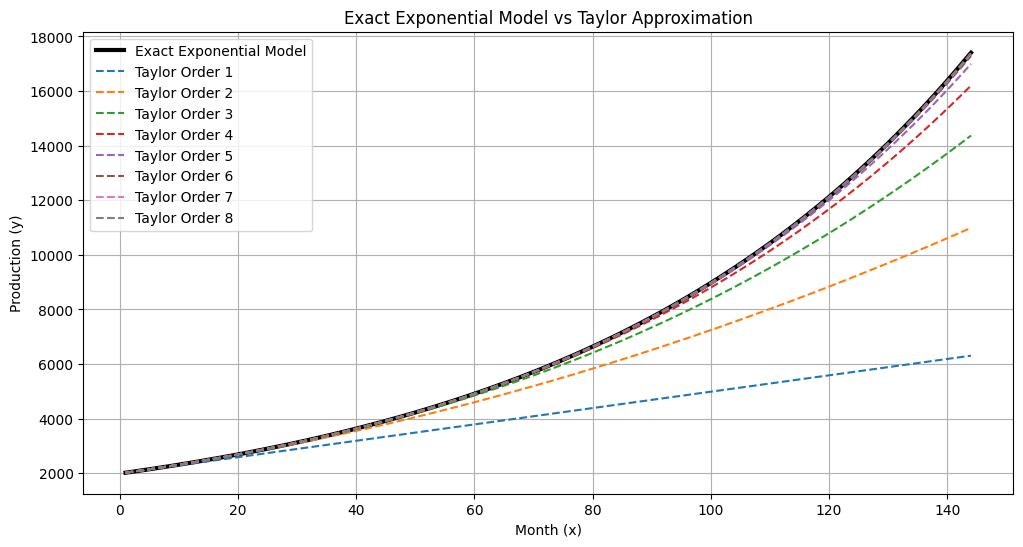

In [10]:
#Visualization
plt.figure(figsize=(12, 6))
plt.plot(x, optimal_func(x), label="Exact Exponential Model", linewidth=3, color='black')

#Define a and b from optimal_params for the Taylor visualization
a, b = optimal_params

for n in range(1, 9):
    y_taylor_n = taylor_approx(x, a, b, n_terms=n + 1)
    plt.plot(x, y_taylor_n, label=f"Taylor Order {n}", linestyle='--')

plt.xlabel("Month (x)")
plt.ylabel("Production (y)")
plt.title("Exact Exponential Model vs Taylor Approximation")
plt.legend()
plt.grid(True)
plt.show()

The 20-term Taylor Series provides an extremely close approximation to the exponential model, with an absolute error of only 4.7985 × 10^-9 at Month 144. This confirms that the numerical approximation is stable and sufficiently accurate for the subsequent analysis.

### **C. Root Finding for Warehouse Prediction**

In [11]:
#Define
capacity = 25000

def f(x):
    return a*np.exp(b*x) - capacity
def df(x):
    return a*b*np.exp(b*x)

In [12]:
#Define Newton Raphson
def newton_raphson(x0= 170, tol= 1e-6, max_iter= 20):
    x = float(x0)
    print("Newton-Raphson Iterations (Exponential Model)")
    print("-" * 75)
    print(f"{'Iter':<4} {'x':<12} {'f(x)':<15} {"f'(x)":<15} {'delta':<15} {'x_new':<15}")
    print("-" * 75)

    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)
        delta = fx/dfx
        x_new = x - delta

        print(f"{i+1:<4} {x:<12.3f} {fx:<15.3f} {dfx:<15.3f} {delta:<15.3f} {x_new:<12.3f}")

        if abs(fx) < tol:
            print("-" * 75)
            print(f"Converged after {i} iterations!")
            return x_new
        x = x_new
    return x

month_exceed = newton_raphson(x0= 170, tol= 1e-6, max_iter= 20)
print(f"\nProduction reaches 25.000 bags at month \u2248 {month_exceed:.3f}")

Newton-Raphson Iterations (Exponential Model)
---------------------------------------------------------------------------
Iter x            f(x)            f'(x)           delta           x_new          
---------------------------------------------------------------------------
1    170.000      742.091         387.547         1.915           168.085     
2    168.085      10.594          376.534         0.028           168.057     
3    168.057      0.002           376.375         0.000           168.057     
4    168.057      0.000           376.375         0.000           168.057     
---------------------------------------------------------------------------
Converged after 3 iterations!

Production reaches 25.000 bags at month ≈ 168.057


In [13]:
#Convert to calendar
def month_to_date(month_float):
    month_int = int(np.ceil(month_float))
    year  = 2018 + (month_int - 1) // 12
    month_num = (month_int - 1) % 12 + 1
    month_names = ["January","February","March","April","May","June",
                   "July","August","September","October","November","December"]
    return month_int, f"{month_names[month_num-1]} {year}"

#Results with month number
exceed_month_idx, exceed_date = month_to_date(month_exceed)
start_build_month_idx = month_exceed - 13
start_month_idx, start_date   = month_to_date(start_build_month_idx)

print(f"Capacity 25.000 bags will be exceeded in Month {exceed_month_idx:<4}({exceed_date})")
print(f"Construction of new warehouse must start 13 months earlier Month {start_month_idx:<4}({start_date})")

Capacity 25.000 bags will be exceeded in Month 169 (January 2032)
Construction of new warehouse must start 13 months earlier Month 156 (December 2030)


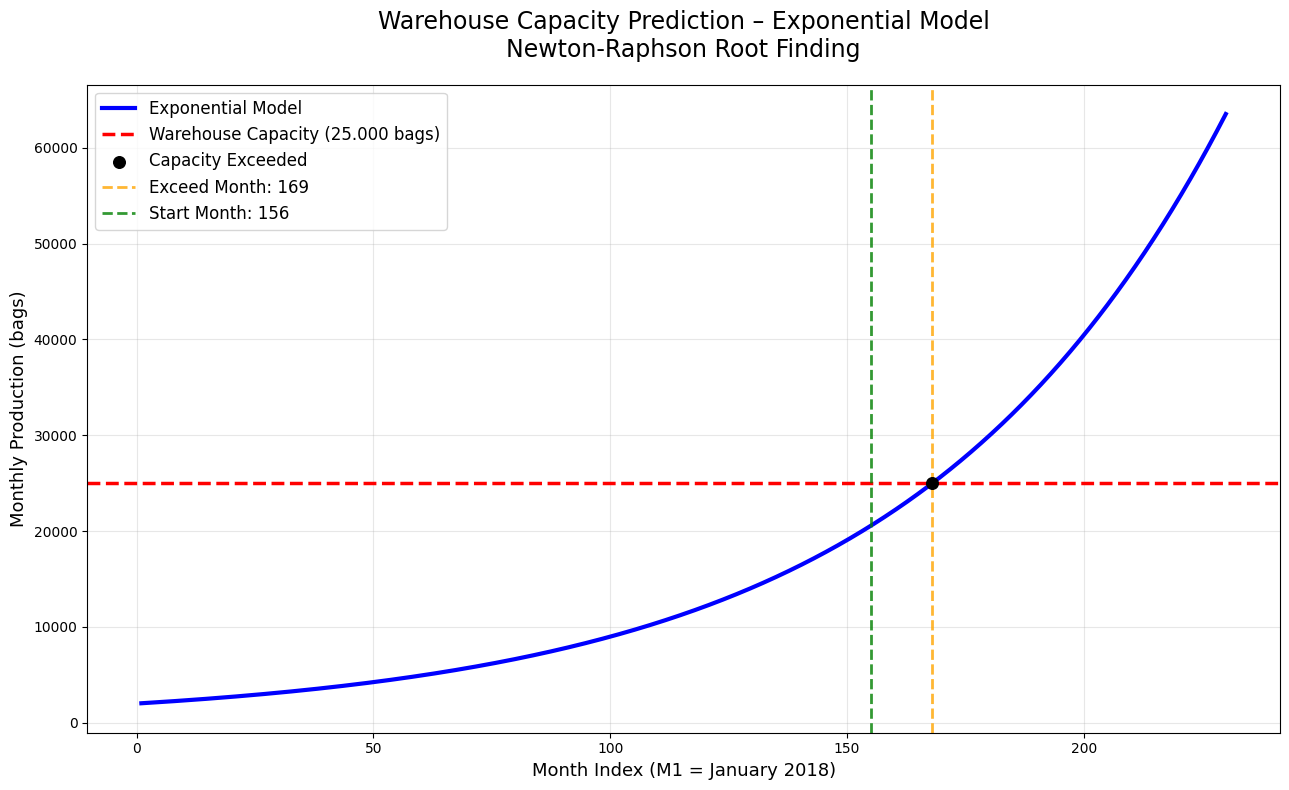

In [14]:
#Visualization
x = np.linspace(1, 230, 2000)
production = a*np.exp(b*x)

plt.figure(figsize=(13, 8))
plt.plot(x, production, 'b-', linewidth=3, label='Exponential Model')
plt.axhline(capacity, color='red', linestyle='--', linewidth=2.5,
            label='Warehouse Capacity (25.000 bags)')
plt.scatter([month_exceed], [capacity],
            color= 'black', s=70, zorder=10, label='Capacity Exceeded')
plt.axvline(month_exceed, color='orange', linestyle='--', linewidth=2, alpha=0.8, label= f"Exceed Month: {exceed_month_idx}")
plt.axvline(start_build_month_idx, color='green', linestyle='--', linewidth=2, alpha=0.8, label= f"Start Month: {start_month_idx}")

plt.title('Warehouse Capacity Prediction – Exponential Model\nNewton-Raphson Root Finding',
          fontsize=17, pad=20)
plt.xlabel('Month Index (M1 = January 2018)', fontsize=13)
plt.ylabel('Monthly Production (bags)', fontsize=13)

plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Newton-Raphson method estimates that production will reach the warehouse's 25,000-unit capacity at approximately Month 168. With a 13-month construction lead time, warehouse expansion should begin by Month 156 (December 2030) to avoid exceeding the existing capacity.

### **D. Numerical Differentiation and Integration**

D.1 Monthly rate of change using central difference for 2020 (M25-M36) and 2021 (M37-M48)

In [15]:
#Numerical Differentiation
def central_diff_O4(y, h=1):
    n = len(y)
    cd = np.zeros(n)

    for i in range(2, n-2):
        cd[i] = (-y[i+2] + 8*y[i+1] - 8*y[i-1] + y[i-2]) / (12*h)

    cd[0] = (y[1] - y[0]) / h
    cd[1] = (y[2] - y[0]) / (2*h)
    cd[-2] = (y[-1] - y[-3]) / (2*h)
    cd[-1] = (y[-1] - y[-2]) / h

    return cd

rate = central_diff_O4(y)

In [16]:
# 2020: M25-M36 (indices 24-35)
idx_2020 = np.arange(24, 36)
rate_2020 = rate[idx_2020]
avg_2020 = np.mean(rate_2020)
steep_inc_2020_idx = np.argmax(rate_2020) + 25
steep_dec_2020_idx = np.argmin(rate_2020) + 25
steep_inc_rate_2020 = rate_2020[np.argmax(rate_2020)]
steep_dec_rate_2020 = rate_2020[np.argmin(rate_2020)]

# 2021: M37-M48 (indices 36-47)
idx_2021 = np.arange(36, 48)
rate_2021 = rate[idx_2021]
avg_2021 = np.mean(rate_2021)
steep_inc_2021_idx = np.argmax(rate_2021) + 37
steep_dec_2021_idx = np.argmin(rate_2021) + 37
steep_inc_rate_2021 = rate_2021[np.argmax(rate_2021)]
steep_dec_rate_2021 = rate_2021[np.argmin(rate_2021)]

print("=" * 62)
print(f"Avg Rate (2020): {avg_2020:.3f} units/month")
print("=" * 62)
print(f"Steepest Inc Month (2020): {steep_inc_2020_idx} with Rate: +{steep_inc_rate_2020:.3f} units/month")
print(f"Steepest Dec Month (2020): {steep_dec_2020_idx} with Rate: {steep_dec_rate_2020:.3f} units/month")
print("=" * 62)
print("\n")
print("=" * 62)
print(f"Avg Rate (2021): {avg_2021:.3f} units/month")
print("=" * 62)
print(f"Steepest Inc Month (2021): {steep_inc_2021_idx}, with Rate: +{steep_inc_rate_2021:.3f} units/month")
print(f"Steepest Dec Month (2021): {steep_dec_2021_idx}, with Rate: {steep_dec_rate_2021:.3f} units/month")
print("=" * 62)

Avg Rate (2020): 25.236 units/month
Steepest Inc Month (2020): 33 with Rate: +449.167 units/month
Steepest Dec Month (2020): 26 with Rate: -428.417 units/month


Avg Rate (2021): 70.528 units/month
Steepest Inc Month (2021): 47, with Rate: +431.417 units/month
Steepest Dec Month (2021): 40, with Rate: -498.500 units/month


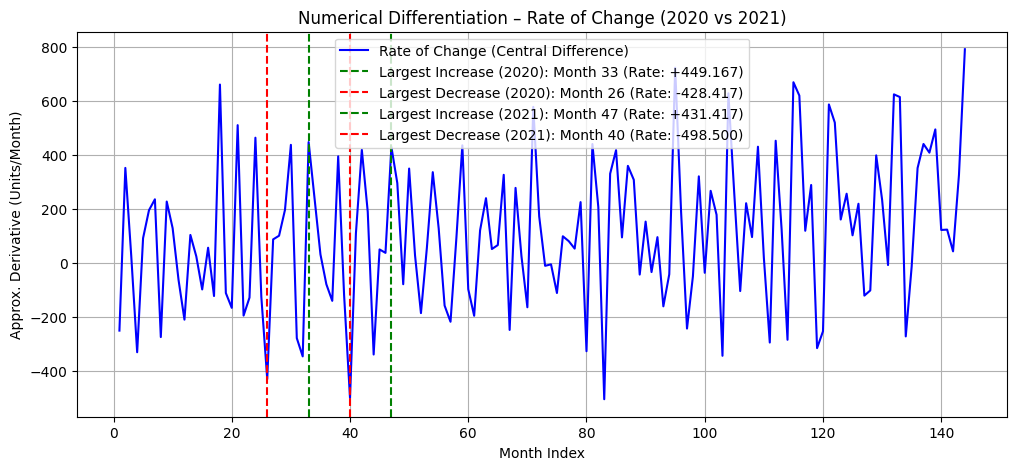

In [17]:
#Visualization
plt.figure(figsize=(12,5))
plt.plot(np.arange(1, len(rate) + 1), rate, label="Rate of Change (Central Difference)", color="blue")
plt.axvline(steep_inc_2020_idx, color='green', linestyle='--', label=f"Largest Increase (2020): Month {steep_inc_2020_idx} (Rate: +{steep_inc_rate_2020:.3f})")
plt.axvline(steep_dec_2020_idx, color='red', linestyle='--', label=f"Largest Decrease (2020): Month {steep_dec_2020_idx} (Rate: {steep_dec_rate_2020:.3f})")
plt.axvline(steep_inc_2021_idx, color='green', linestyle='--', label=f"Largest Increase (2021): Month {steep_inc_2021_idx} (Rate: +{steep_inc_rate_2021:.3f})")
plt.axvline(steep_dec_2021_idx, color='red', linestyle='--', label=f"Largest Decrease (2021): Month {steep_dec_2021_idx} (Rate: {steep_dec_rate_2021:.3f})")

plt.title("Numerical Differentiation – Rate of Change (2020 vs 2021)")
plt.xlabel("Month Index")
plt.ylabel("Approx. Derivative (Units/Month)")
plt.legend()
plt.grid(True)
plt.show()

The numerical differentiation analysis reveals substantial month-to-month volatility in production growth. The steepest increase occurred in 2021 at Month 47, reaching approximately +431.417 units/month. This indicates that production growth was not uniform and that certain periods experienced significantly faster increases than others.

D.2 Total production using Trapezoidal Rule

In [18]:
#Trapezoidal for M1-M72 (Jan 2018 - Dec 2023)
x_subset = np.arange(1, 72 + 1)
y_subset = y[:72]

I_trapez = trapezoid(y_subset, x_subset)
I_actual = np.sum(y_subset)
error = I_actual - I_trapez
percent_error = (error / I_actual) * 100

print("-"*60)
print(f"Trapezoidal Approximation: {I_trapez:.3f}")
print("-"*60)
print(f"Actual Total Production (Sum of monthly values): {I_actual:.3f}")
print(f"Error (Actual - Trapezoidal): {error:.3f}")
print(f"Percentage Error: {percent_error:.3f}%")

------------------------------------------------------------
Trapezoidal Approximation: 255567.000
------------------------------------------------------------
Actual Total Production (Sum of monthly values): 259616.000
Error (Actual - Trapezoidal): 4049.000
Percentage Error: 1.560%


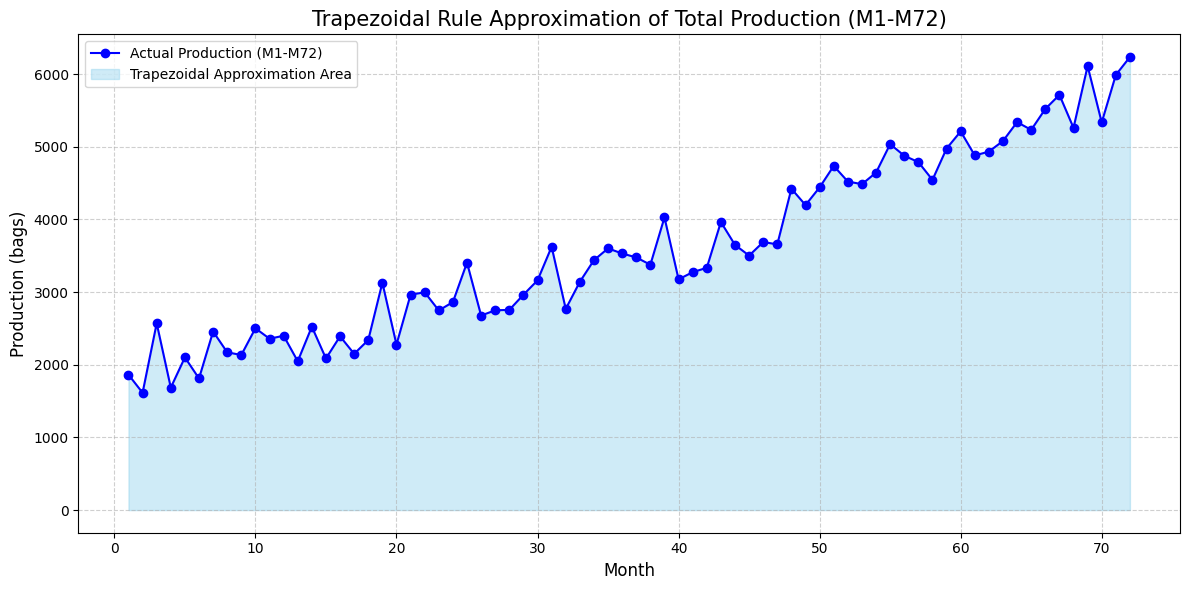

In [19]:
#Visualization
plt.figure(figsize=(12, 6))
plt.plot(x_subset, y_subset, 'o-', color='blue', label='Actual Production (M1-M72)')
plt.fill_between(x_subset, 0, y_subset, color='skyblue', alpha=0.4, label='Trapezoidal Approximation Area')

plt.title('Trapezoidal Rule Approximation of Total Production (M1-M72)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Production (bags)', fontsize=12)
plt.xticks(np.arange(0, len(x_subset) + 1, 10))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

The Trapezoidal Rule estimates a cumulative production volume of 255,567 units, compared with an actual summed production of 259,616 units. The resulting 1.560% error indicates that the numerical integration provides a reasonably close approximation of the cumulative production volume.